<a href="https://colab.research.google.com/github/OmkarRahate2004/Thiranex_Internship/blob/main/Thiranex_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('netflix_titles.csv')

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe(include='all'))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(
    df['rating'].mode()[0]
)
df['date_added'] = df['date_added'].fillna(
    'Unknown'
)
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [8]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

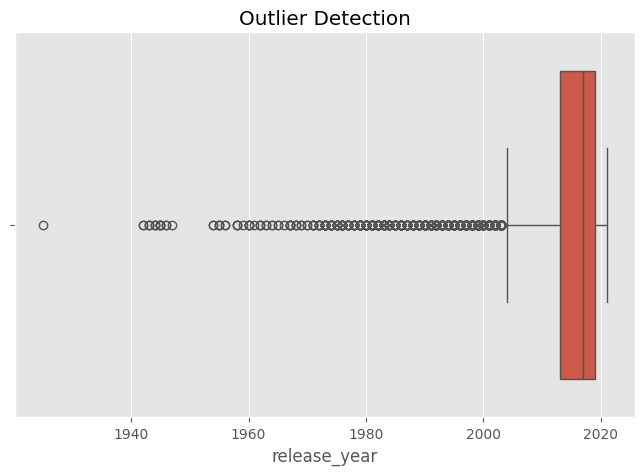

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df['release_year']
)
plt.title('Outlier Detection')
plt.show()

In [10]:
df.to_csv(
    'cleaned_netflix_dataset.csv',
    index=False
)

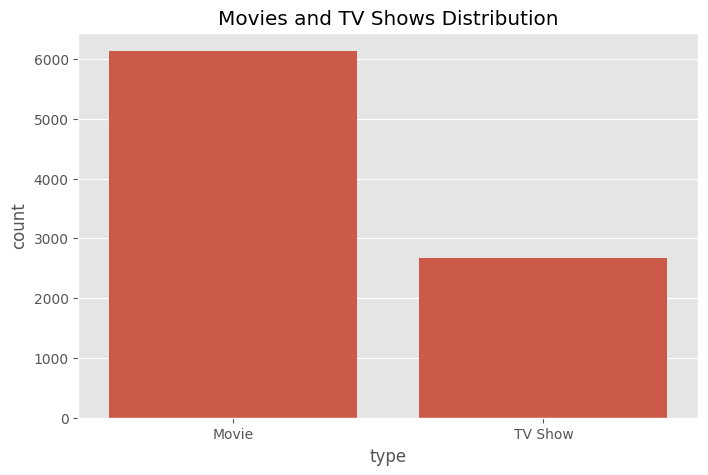

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='type',
    data=df
)
plt.title('Movies and TV Shows Distribution')
plt.show()

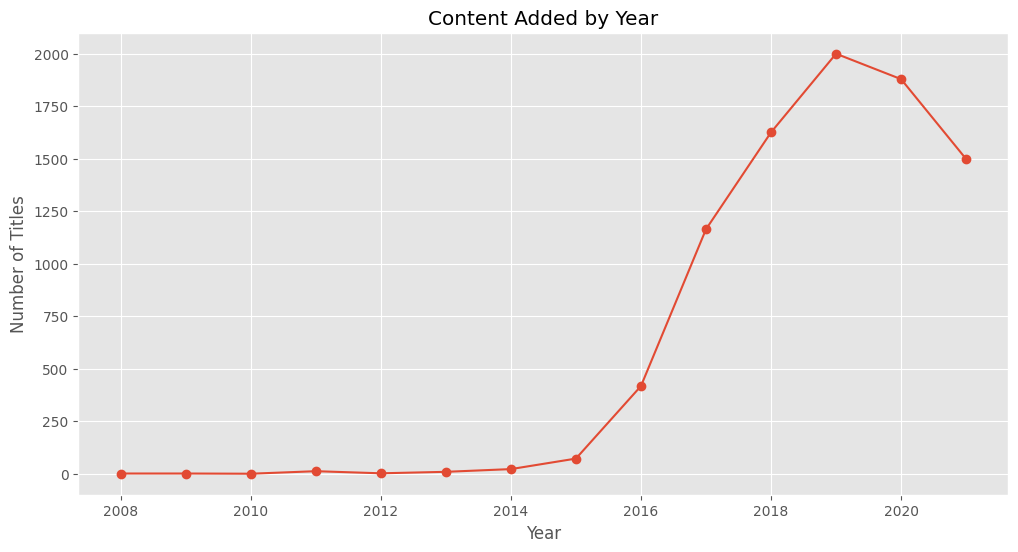

In [12]:
plt.figure(figsize=(12,6))
df['year_added'].value_counts()\
.sort_index()\
.plot(kind='line',
      marker='o')
plt.title('Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

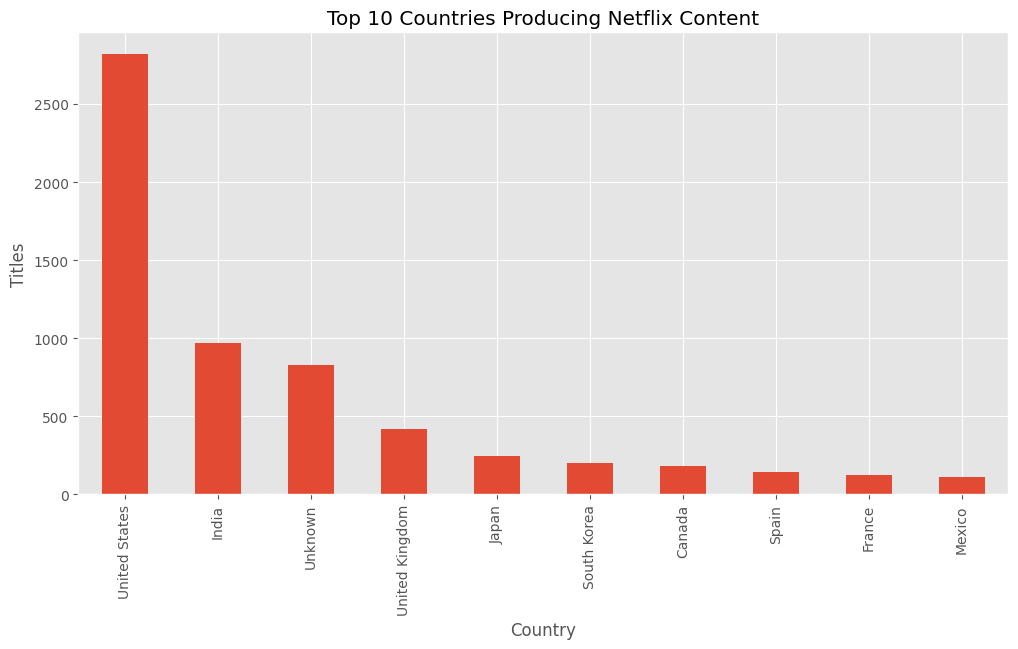

In [13]:
top_country = (
    df['country']
    .value_counts()
    .head(10)
)
plt.figure(figsize=(12,6))
top_country.plot(
    kind='bar'
)
plt.title(
    'Top 10 Countries Producing Netflix Content'
)
plt.xlabel('Country')
plt.ylabel('Titles')
plt.show()

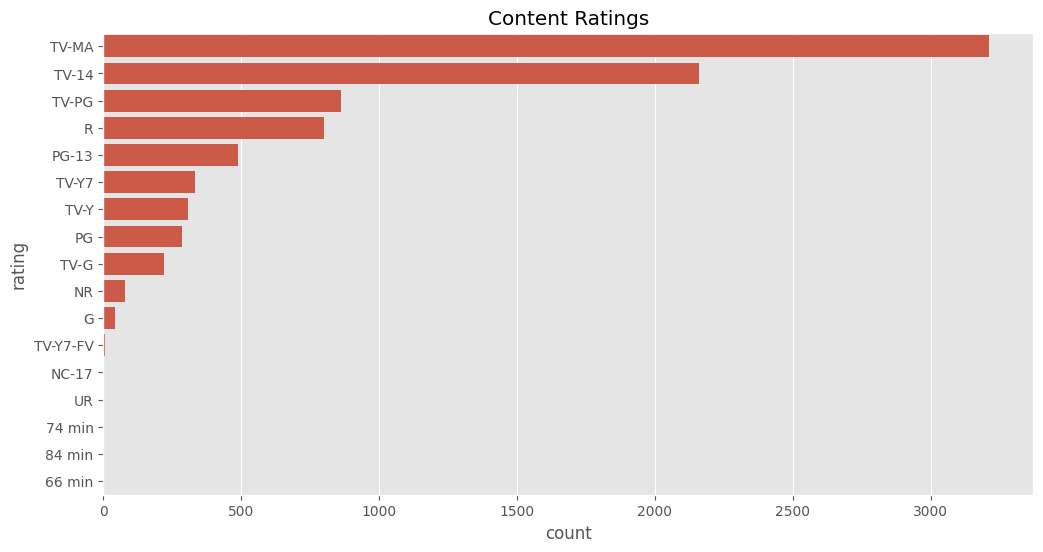

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating']
    .value_counts()
    .index
)
plt.title('Content Ratings')
plt.show()

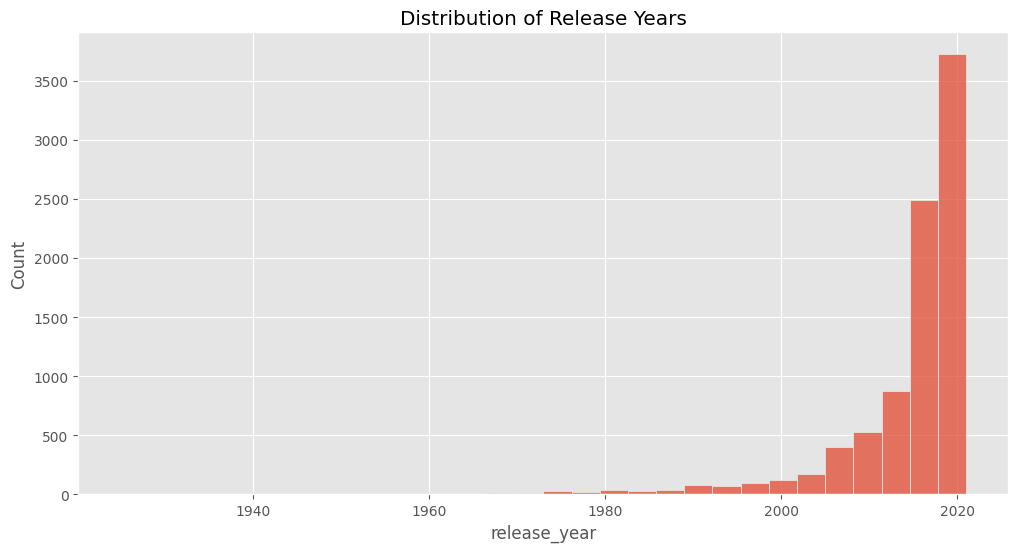

In [15]:
plt.figure(figsize=(12,6))
sns.histplot(
    df['release_year'],
    bins=30
)
plt.title(
    'Distribution of Release Years'
)
plt.show()

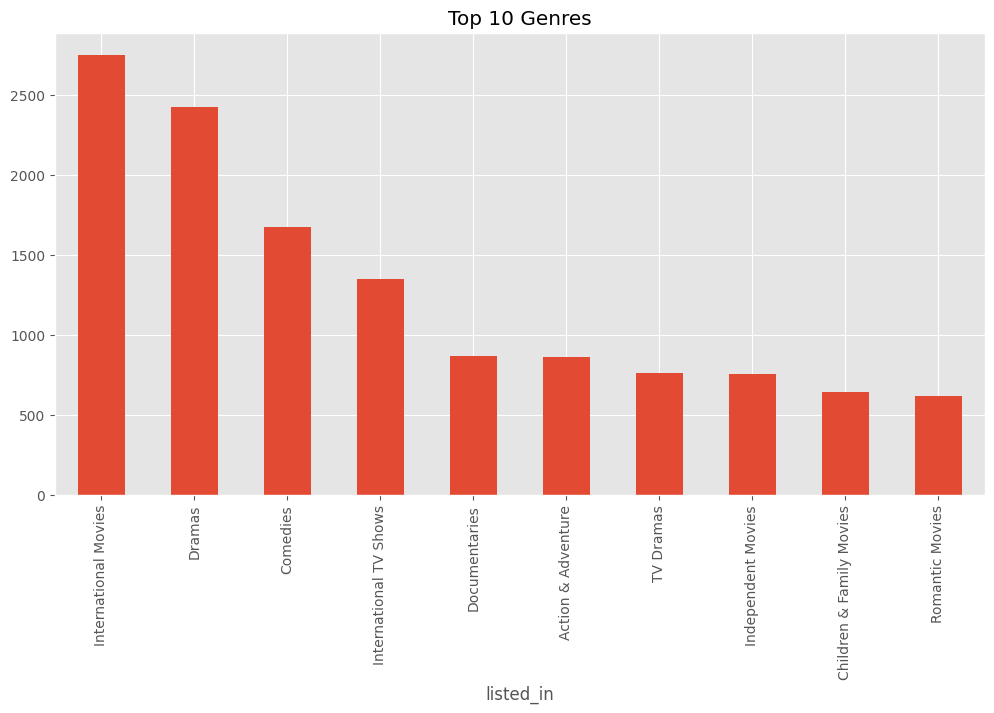

In [16]:
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)
top_genres = (
    genres
    .value_counts()
    .head(10)
)
plt.figure(figsize=(12,6))
top_genres.plot(
    kind='bar'
)
plt.title('Top 10 Genres')
plt.show()

In [17]:
total_titles = len(df)
movies = len(
    df[df['type']=='Movie']
)
tv_shows = len(
    df[df['type']=='TV Show']
)
countries = (
    df['country']
    .nunique()
)
print("Total Titles:", total_titles)
print("Movies:", movies)
print("TV Shows:", tv_shows)
print("Countries:", countries)

Total Titles: 8807
Movies: 6131
TV Shows: 2676
Countries: 749
